Mounted at /content/drive
Loading dataset...
Filling missing values using training-set medians only...
Training Random Forest...

===== PERFORMANCE =====
RMSE: 0.2071
MAE : 0.1486
R2  : 0.9110


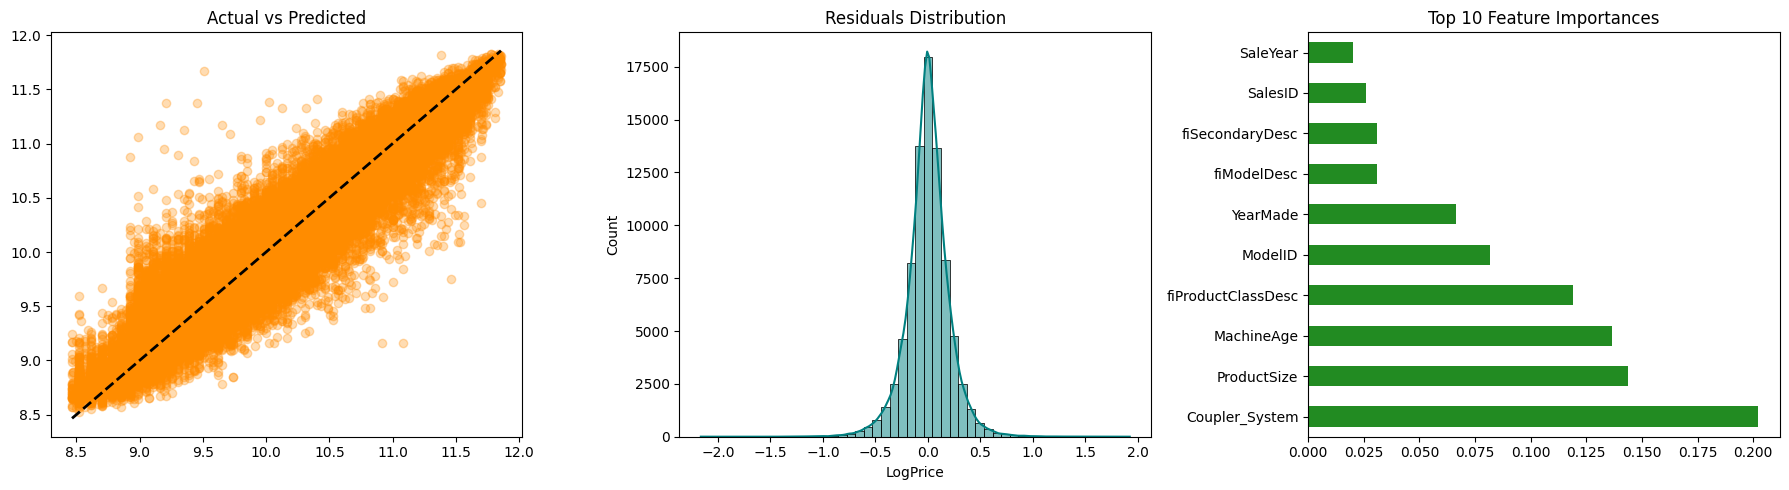

In [2]:
"""
Group 2
Obil Nathaniel - 271048001
Muhammad Abdullah - 281134982
"""
# ============================
# EXPERIMENT 2: RANDOM FOREST (LEAK-PROOF VERSION)
# ============================
"""
OVERVIEW: This notebook uses a 'Forest' of 100 decision trees.
We have moved the Median Imputation step AFTER the
train-test split to ensure no data from the test set leaks into training.

STEPS:
1. TARGET SCALING: Log transform to handle right-skewed pricing data.
2. FEATURE ENGINEERING: Created 'MachineAge' and 'DayOfWeek'.
3. CATEGORICAL ENCODING: Converted strings to numeric codes globally
   (safe, as category labels are fixed).
4. DATA SPLITTING: 80/20 split using random_state=42.
5. IMPUTATION: Calculated medians using ONLY the training set,
   then applied those values to the test set.
6. MODELING: Trained 100 trees using all available CPU cores.
"""

# Imports
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from google.colab import drive
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

# ----------------------------
# 1. Mount & Load
# ----------------------------
drive.mount('/content/drive')
file_path = '/content/drive/MyDrive/ML/TrainAndValid.csv'

print("Loading dataset...")
df = pd.read_csv(file_path, low_memory=False)

# ----------------------------
# 2. Target & Temporal Preprocessing
# ----------------------------
df['LogPrice'] = np.log(df['SalePrice'])
df['saledate'] = pd.to_datetime(df['saledate'])
df['SaleYear'] = df['saledate'].dt.year
df['SaleMonth'] = df['saledate'].dt.month
df['SaleDay'] = df['saledate'].dt.day
df['DayOfWeek'] = df['saledate'].dt.dayofweek
df.drop('saledate', axis=1, inplace=True)

df['YearMade'] = df['YearMade'].replace(1000, np.nan)
df['MachineAge'] = df['SaleYear'] - df['YearMade']

# ----------------------------
# 3. Global Categorical Encoding
# ----------------------------
# Encoding labels is safe before splitting because the "vocabulary"
# of brand names/sizes is fixed.
for label, content in df.items():
    if pd.api.types.is_string_dtype(content) or pd.api.types.is_object_dtype(content):
        df[label] = content.astype("category").cat.as_ordered()
        df[label] = df[label].cat.codes + 1

# ----------------------------
# 4. Train-Test Split (The Shield)
# ----------------------------
X = df.drop(['SalePrice', 'LogPrice'], axis=1)
y = df['LogPrice']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# ----------------------------
# 5. Leak-Proof Imputation
# ----------------------------
print("Filling missing values using training-set medians only...")

for label, content in X_train.items():
    if pd.api.types.is_numeric_dtype(content):
        if pd.isnull(content).sum():
            # Calculate median using ONLY training data
            train_median = content.median()
            # Apply that training median to both sets
            X_train[label] = X_train[label].fillna(train_median)
            X_test[label] = X_test[label].fillna(train_median)

# ----------------------------
# 6. Modeling
# ----------------------------
print("Training Random Forest...")
model_rf = RandomForestRegressor(n_estimators=100, n_jobs=-1, random_state=42)
model_rf.fit(X_train, y_train)

# ----------------------------
# 7. Evaluation & Visuals
# ----------------------------
y_pred = model_rf.predict(X_test)

print("\n===== PERFORMANCE =====")
print(f"RMSE: {np.sqrt(mean_squared_error(y_test, y_pred)):.4f}")
print(f"MAE : {mean_absolute_error(y_test, y_pred):.4f}")
print(f"R2  : {r2_score(y_test, y_pred):.4f}")

plt.figure(figsize=(18, 5))
plt.subplot(1, 3, 1)
plt.scatter(y_test, y_pred, alpha=0.3, color='darkorange')
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'k--', lw=2)
plt.title("Actual vs Predicted")

plt.subplot(1, 3, 2)
sns.histplot(y_test - y_pred, bins=50, kde=True, color='teal')
plt.title("Residuals Distribution")

plt.subplot(1, 3, 3)
importances = pd.Series(model_rf.feature_importances_, index=X.columns)
importances.nlargest(10).plot(kind='barh', color='forestgreen')
plt.title("Top 10 Feature Importances")
plt.tight_layout()
plt.show()